# Chemical Equilibrium Transmission Spectra

This tutorial demonstrates how to access a chemical equilibrium grid and use it compute model transmission spectra.

In [2]:
import POSEIDON
POSEIDON.__file__

'/Users/elijahmullens/Desktop/POSEIDON-VULCAN/POSEIDON/__init__.py'

In [3]:
from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_J, M_J

#***** Define stellar properties *****#

R_s = 0.9*R_Sun   # Stellar radius (m)
T_s = 5400          # Stellar effective temperature (K)
Met_s = 0.01        # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.45        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s)

#***** Define planet properties *****#

planet_name = 'WASP-39 b'  # Planet name used for plots, output files etc.

R_p = 1.27*R_J     # Planetary radius (m)
M_p = 0.28*M_J       # Planetary mass (kg)
T_eq = 1116           # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq)

In [4]:
from POSEIDON.core import define_model
import numpy as np

#***** Define models *****#

model_name_1 = 'eq_chemistry_full'   
model_name_2 = 'eq_chemistry_subset'

bulk_species = ['H2', 'He']      # H2 + He comprises the bulk atmosphere

param_species_full = ['all']
param_species_subset = ['H','H2O', 'CH4', 'CO', 'CO2']

model_subset = define_model(model_name_2, bulk_species, param_species_subset, 
                            X_profile = 'chem_diseq',
                            diseq_grid_name = "VULCAN_Grid1.1",
                            )

In [11]:
print(model_subset['X_param_names'])
print(model_subset['PT_param_names'])

['C_O' 'log_met']
['log_kappa_IR' 'T_equ']


In [5]:
from POSEIDON.chemistry import load_vulcan_chemistry_grid

# Load the subset chemical equilibrium grid
chemistry_grid_subset = load_vulcan_chemistry_grid(param_species_subset, grid = "VULCAN_Grid1.1")

Reading in database for VULCAN model...


### Load Opacities

In [6]:
from POSEIDON.core import wl_grid_constant_R, read_opacities

#***** Wavelength grid *****#
 
wl_min = 0.5       # Minimum wavelength (um)
wl_max = 13       # Maximum wavelength (um)
R = 5000          # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# First, specify limits of the fine temperature and pressure grids for the 
# pre-interpolation of cross sections. These fine grids should cover a
# wide range of possible temperatures and pressures for the model atmosphere.

# Define fine temperature grid (K)
T_fine_min = 100     # 400 K lower limit suffices for a typical hot Jupiter
T_fine_max = 10000    # 2000 K upper limit suffices for a typical hot Jupiter
T_fine_step = 20     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step), 
                       log_P_fine_step)

# Pre-interpolate the sampled opacities for both models (the subset will be faster!)
opac_subset = read_opacities(model_subset, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2-H done
H2-CH4 done
CO2-H2 done
CO2-CO2 done
CO2-CH4 done
H2O done
CH4 done
CO done
CO2 done
Opacity pre-interpolation complete.


As you can see, one disadvantage of using the full equilibrium database is that more time and RAM is required to handle all the opacities. If you know *a priori* that a given chemical species is not important (e.g. its absorption features lie outside the wavelength range you are modelling), consider using a subset model excluding the non-important chemical species.

### Compute Transmission Spectrum

Now we can create transmission spectra for both the full equilibrium model and the subset model.

# Ryan C Code

In [24]:
#! /usr/bin/env python

import numpy as np
import matplotlib.pyplot as plt
import time

tic = time.time()

# Some silly model
def model(wl, x, y, z):
    return x + y*np.sin(wl) + z * np.cos(wl)**2

# Calculate a grid
def calcgrid(wl, xs, ys, zs):
    nx = len(xs)
    ny = len(ys)
    nz = len(zs)
    
    grid = np.zeros((nx, ny, nz, nwl))

    for ix, x in enumerate(xs):
        for iy, y in enumerate(ys):
            for iz, z in enumerate(zs):
                grid[ix, iy, iz] = model(wl, x, y, z)

    return grid

# Initial grid
nx = 10
ny = 10
nz = 10

xs = np.linspace(0, 10, nx)
ys = np.linspace(0, 2*np.pi, ny)
zs = np.linspace(0, 2*np.pi, nz)

axes = [xs, ys, zs]

nwl = 100
wl = np.linspace(1, 10, nwl)

grid = calcgrid(wl, axes[0], axes[1], axes[2])

nvar = len(axes)

# Absolute tolerance (models must differ by less than this everywhere)
tol = 0.1

# Flage to tell when we're done
done = False

# Track iterations out of curiosity (could limit by this also)
niter = 0

while not done:
    donebools = np.ones(len(axes), dtype=bool)

    # Loop over variable axes
    for i in range(nvar):
        # Calculate differences between slices 
        diffs = np.diff(grid, axis=i)
        # List of where we need to insert new values
        insertind = []
        # Loop over the slices for this axis
        for j in range(diffs.shape[i]):
            # Slice the differences along the dimension corresponding
            # to this axis. Trust me.
            indx = [slice(None)] * diffs.ndim
            indx[i] = j
            indx = tuple(indx)
            # Check if the maximum difference of this slice is below
            # the tolerance and, if not, flag this index for insertion
            # a new value later (j+1 because np.insert puts the value
            # *before* the index) and note that we need to recheck
            # this axis.
            if np.max(diffs[indx]) > tol:
                insertind.append(j+1)
                donebools[i] = False

        insertind = np.array(insertind)

        # Insert new values as needed. Use the midpoints.
        if len(insertind) != 0:
            insertval = (axes[i][insertind-1] + axes[i][insertind]) / 2
            axes[i] = np.insert(axes[i], insertind, insertval)

    # Recalculate grid (inefficient -- better to only do new entries)
    grid = calcgrid(wl, axes[0], axes[1], axes[2])

    # Check if we're done with all axes
    niter += 1
    if np.all(donebools):
        done = True

print("Number of iterations: {}".format(niter))
print("Runtime: {:.2f} seconds".format(time.time() - tic))
print("Final grid dimensions: {}".format(grid.shape))

KeyboardInterrupt: 

===VULCAN_Grid1.1===
=Variable parameters=
|   log_kappa_IR               [-3.5, -2.5], step=0.25
|   T_equ (K)                  [700, 1100], step=100
|   C/O                        (0.2, 1, 1.5, 2)
|   log_met                    [-1, 4], step=1
=Fixed parameters=
|   log_gamma                  -1.0
|   T_int (K)                  358
|   log_Kzz (cm/s**2)          10.5

In [8]:
kappa_IR = [-3.5,-3.25,-3.0,-2.75,-2.50]
Teq = [700,800,900,1000,1100]
C_O = [0.2,1,1.5,2]
lot_met = [-1,0,1,2,3,4]

In [67]:
from POSEIDON.core import make_atmosphere
from POSEIDON.core import compute_spectrum


def model(wl, log_kappa_IR, Teq):
    # Specify the pressure grid of the atmosphere
    P_min = 1.0e-6    # 0.1 ubar
    P_max = 10       # 100 bar
    N_layers = 100    # 100 layers

    # We'll space the layers uniformly in log-pressure
    P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

    # Specify the reference pressure and radius
    P_ref = 10.0   # Reference pressure (bar)
    R_p_ref = R_p  # Radius at reference pressure

    T_eq = Teq
    log_kappa_IR = log_kappa_IR

    # Specify carbon to oxygen ratio and metallicity for atmosphere
    C_to_O = 0.55    # C/O
    log_Met = 0.0    # log_10 (metallicity)

    # Provide a specific set of model parameters for the atmosphere 
    PT_params = np.array([log_kappa_IR,Teq])              # T (K)
    X_params = np.array([C_to_O, log_Met])    # The parameters are just C/O and log(Met) for an equilibrium model

    # Generate two atmospheres: one with the full equilibrium grid and one with the subset
    atmosphere_subset = make_atmosphere(planet, model_subset, P, P_ref, R_p_ref, PT_params, 
                                        X_params, chemistry_grid = chemistry_grid_subset,
                                        use_conv_flag= False
                                        )
    
    spectrum_subset = compute_spectrum(planet, star, model_subset, atmosphere_subset, 
                                   opac_subset, wl, spectrum_type = 'transmission')
    print(spectrum_subset)
    
    return spectrum_subset

In [68]:
#! /usr/bin/env python

import numpy as np
import matplotlib.pyplot as plt
import time

tic = time.time()

# Calculate a grid
def calcgrid(wl, xs, ys):
    nx = len(xs)
    ny = len(ys)
    nwl = len(wl)
    
    grid = np.zeros((nx, ny, nwl))

    for ix, x in enumerate(xs):
        for iy, y in enumerate(ys):
            grid[ix, iy] = model(wl, x, y)

    return grid

# Initial grid
# 2 by 2 for now for ease of visualization
# Have to be arrays for Ryan's code to work
log_kappa_IR_array = np.array([-3.5,-3.25,-3.0,-2.75,-2.50])
Teq_array = np.array([700,800,900,1000,1100])

nx = len(log_kappa_IR_array)
ny = len(Teq_array)

xs = log_kappa_IR_array
ys = Teq

axes = [xs, ys]

#***** Wavelength grid *****#
 
wl_min = 0.5       # Minimum wavelength (um)
wl_max = 13       # Maximum wavelength (um)
R = 5000          # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, R)

grid = calcgrid(wl, axes[0], axes[1])


[0.02403121 0.02403092 0.02403042 ... 0.02413119 0.02401306 0.02480144]
[0.02429422 0.02429385 0.02429334 ... 0.02449557 0.02430931 0.02562111]
[0.02458665 0.02458618 0.02458569 ... 0.02487857 0.02465737 0.02600404]
[0.02490507 0.02490452 0.02490406 ... 0.02525641 0.02504713 0.0261518 ]
[0.02524563 0.02524501 0.02524452 ... 0.02561369 0.02545375 0.02614618]
[0.02430869 0.02430834 0.02430786 ... 0.02442982 0.02428099 0.02518592]
[0.02454941 0.02454899 0.02454848 ... 0.02478509 0.02457832 0.0259206 ]
[0.0248212  0.02482069 0.02482022 ... 0.02516793 0.0249523  0.02621465]
[0.02512114 0.02512053 0.0251201  ... 0.02556669 0.02538931 0.02634019]
[0.02544605 0.02544536 0.02544487 ... 0.02594299 0.02584321 0.0263716 ]
[0.0246518  0.02465141 0.02465091 ... 0.02481759 0.02462672 0.02571243]
[0.02486721 0.02486674 0.02486624 ... 0.02513332 0.02491829 0.02625398]
[0.02511041 0.02510983 0.02510945 ... 0.02562899 0.02541976 0.02680984]
[0.02538706 0.02538637 0.02538607 ... 0.02607622 0.02593211 0.02

Visualize

[[0.00056546 0.00148745 0.0038157  0.0054892  0.        ]
 [0.00250539 0.00300938 0.00177184 0.00504871 0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


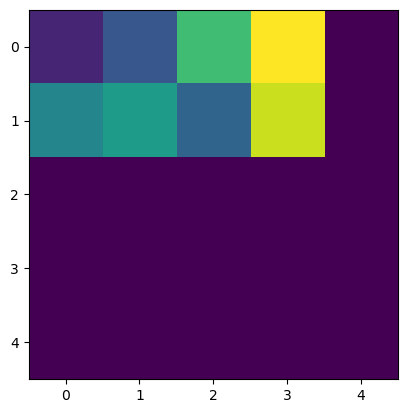

In [71]:
max_diff_array = np.zeros((len(log_kappa_IR_array),len(Teq_array)))


# Loop over variable axes
for i in range(nvar):
    # Calculate differences between slices 
    diffs = np.diff(grid, axis=i)
    # List of where we need to insert new values
    insertind = []
    # Loop over the slices for this axis
    for j in range(diffs.shape[i]):
        # Slice the differences along the dimension corresponding
        # to this axis. Trust me.
        # Will do!
        indx = [slice(None)] * diffs.ndim
        indx[i] = j
        indx = tuple(indx)
        # Check if the maximum difference of this slice is below
        # the tolerance and, if not, flag this index for insertion
        # a new value later (j+1 because np.insert puts the value
        # *before* the index) and note that we need to recheck
        # this axis.
        max_diff_array[i,j] = (np.max(diffs[indx]))

print(max_diff_array)

plt.imshow(max_diff_array)

Find new points to add

In [ ]:
# Loop over variables that remake axis 
nvar = len(axes)

# Absolute tolerance (models must differ by less than this everywhere)
tol = 1e-5

# Flage to tell when we're done
done = False

# Track iterations out of curiosity (could limit by this also)
niter = 0

print("Initial grid dimensions: {}".format(grid.shape))

while not done:
    donebools = np.ones(len(axes), dtype=bool)

    # Loop over variable axes
    for i in range(nvar):
        # Calculate differences between slices 
        diffs = np.diff(grid, axis=i)
        # List of where we need to insert new values
        insertind = []
        # Loop over the slices for this axis
        for j in range(diffs.shape[i]):
            # Slice the differences along the dimension corresponding
            # to this axis. Trust me.
            # Will do!
            indx = [slice(None)] * diffs.ndim
            indx[i] = j
            indx = tuple(indx)
            # Check if the maximum difference of this slice is below
            # the tolerance and, if not, flag this index for insertion
            # a new value later (j+1 because np.insert puts the value
            # *before* the index) and note that we need to recheck
            # this axis.
            if np.max(diffs[indx]) > tol:
                insertind.append(j+1)
                donebools[i] = False

        insertind = np.array(insertind)

        # Insert new values as needed. Use the midpoints.
        if len(insertind) != 0:
            insertval = (axes[i][insertind-1] + axes[i][insertind]) / 2
            axes[i] = np.insert(axes[i], insertind, insertval)

    # Recalculate grid (inefficient -- better to only do new entries)
    # This makes everything rectangular again, so will be important to compute new values of grid for Vulcan
    # grid = calcgrid(wl, axes[0], axes[1], axes[2])
    # Ignoring this step since we would need to compute Vulcan first

    # Only one iteration 
    niter += 1
    done = True

print("Number of iterations: {}".format(niter))
print("Runtime: {:.2f} seconds".format(time.time() - tic))
print()
print("Old Kappa Ir: ", log_kappa_IR_array)
print("New Kappa_IR: {}".format(axes[0]))
print()
print("Old T equ ", Teq_array)
print("New T equ: {}".format(axes[1]))

Initial grid dimensions: (5, 5, 16290)
Number of iterations: 1
Runtime: 3.69 seconds

Old Kappa Ir:  [-3.5  -3.25 -3.   -2.75 -2.5 ]
New Kappa_IR: [-3.5   -3.375 -3.25  -3.125 -3.    -2.875 -2.75  -2.625 -2.5  ]

Old T equ  [ 700  800  900 1000 1100]
New T equ: [ 700  750  800  850  900  950 1000 1050 1100]
